## Bibliotecas

In [16]:
#import packages
import pandas as pd
import numpy as np
import os
import warnings
import optuna
from sklearn.metrics import root_mean_squared_error, mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
import shap
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

## Configurações

In [17]:
# Definir diretório
os.chdir('/home/joao/Área de Trabalho/tese')

# Evitar avisos
warnings.filterwarnings('ignore')

In [18]:
#load dataset
df = pd.read_excel('df_conjunto_poa.xlsx')

In [19]:
#rename columns
df = df.rename(columns={
    'semana':'week',
    'cesta_dieese':'dieese_basket',
    'carne':'meat',
    'leite':'milk',
    'feijao':'bean',
    'arroz':'rice',
    'farinha':'flour',
    'batata':'potato',
    'tomate':'tomato',
    'pao':'bread',
    'cafe':'coffee',
    'acucar':'sugar',
    'oleo':'lard/oil',
    'manteiga':'butter',
    'cesta_online':'online'
})

In [20]:
df.columns

Index(['week', 'dieese_basket', 'meat', 'milk', 'bean', 'rice', 'flour',
       'potato', 'tomato', 'bread', 'coffee', 'banana', 'sugar', 'lard/oil',
       'butter', 'online'],
      dtype='object')

In [21]:
#create lagged dataset
k = 1 #number of lags
y_lag = df[['week','dieese_basket']][k:]
x_lag = df.copy()
x_lag = x_lag.drop(['week','dieese_basket'], axis=1)
x_lag = x_lag[:len(df)-k]
y_lag = y_lag.reset_index(drop=True)
x_lag = x_lag.reset_index(drop=True)
df_lag = pd.concat([y_lag,x_lag], axis=1)

In [22]:
#set X and y
X = df_lag.copy()
X = X.drop(['week','dieese_basket','online'], axis=1)
y = df_lag['dieese_basket'] 

In [23]:
def calculate_mape(y_true, y_pred):
    mask = y_true != 0
    if mask.sum() == 0:
        return 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

## Random forest

In [24]:
#function Optuna -- RF
def objective(trial):
    # 1. Define hyperparameters to tune
    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    max_leaf_nodes = trial.suggest_int('max_leaf_nodes', 2, 256)
    min_samples_split = trial.suggest_int('min_samples_split', 5, 100)
    max_depth = trial.suggest_int('max_depth', 5, 20, log=True)
    
    # 2. Expanding window parameters
    initial_train_size = 10  # Starting length of training data
    step_size = 1            # How much to expand the window per step
    total_samples = len(X)
    
    scores = []
    
    # 3. Walk-forward expanding window loop
    for train_end in range(initial_train_size, total_samples, step_size):
        X_train = X[:train_end]
        y_train = y[:train_end]
        
        # Validation window directly follows the training window
        X_val = X[train_end:train_end + step_size]
        y_val = y[train_end:train_end + step_size]
        
        if len(y_val) == 0:
            break
            
        # 4. Train and predict
        model = RandomForestRegressor(
            n_estimators=n_estimators,
            max_leaf_nodes=max_leaf_nodes,
            min_samples_split=min_samples_split,
            max_depth=max_depth,
            random_state=42
        )
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        
        # 5. Evaluate and store score
        rmse = root_mean_squared_error(y_val, preds)
        scores.append(rmse)
        
    # Return the mean error across all expanding window splits
    return np.mean(scores)

In [25]:
#run Optuna RF
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=20)

[I 2026-06-29 16:38:40,534] A new study created in memory with name: no-name-f6f7918c-0144-49d0-9002-b37b3dde5428
[I 2026-06-29 16:38:43,321] Trial 0 finished with value: 19.859872270362374 and parameters: {'n_estimators': 106, 'max_leaf_nodes': 244, 'min_samples_split': 75, 'max_depth': 11}. Best is trial 0 with value: 19.859872270362374.
[I 2026-06-29 16:38:45,540] Trial 1 finished with value: 13.016668323808737 and parameters: {'n_estimators': 73, 'max_leaf_nodes': 41, 'min_samples_split': 10, 'max_depth': 17}. Best is trial 1 with value: 13.016668323808737.
[I 2026-06-29 16:38:49,886] Trial 2 finished with value: 11.806495859821231 and parameters: {'n_estimators': 140, 'max_leaf_nodes': 182, 'min_samples_split': 6, 'max_depth': 20}. Best is trial 2 with value: 11.806495859821231.
[I 2026-06-29 16:38:54,931] Trial 3 finished with value: 14.707045674092942 and parameters: {'n_estimators': 175, 'max_leaf_nodes': 56, 'min_samples_split': 22, 'max_depth': 6}. Best is trial 2 with value:

In [26]:
#best hyperparameters RF
print("Best hyperparameters: ", study.best_params)

Best hyperparameters:  {'n_estimators': 194, 'max_leaf_nodes': 144, 'min_samples_split': 5, 'max_depth': 19}


In [27]:
# Treinar modelo final
best_model = RandomForestRegressor(
    n_estimators=study.best_params['n_estimators'],
    max_leaf_nodes=study.best_params['max_leaf_nodes'],
    min_samples_split=study.best_params['min_samples_split'],
    max_depth=study.best_params['max_depth'],
    random_state=42
)

best_model.fit(X, y)
y_pred = best_model.predict(X)

# Calcular métricas
rmse = np.sqrt(mean_squared_error(y, y_pred))
mae = mean_absolute_error(y, y_pred)
mape = calculate_mape(y, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"MAPE: {mape:.4f}%")

RMSE: 4.5287
MAE:  3.5433
MAPE: 0.4527%


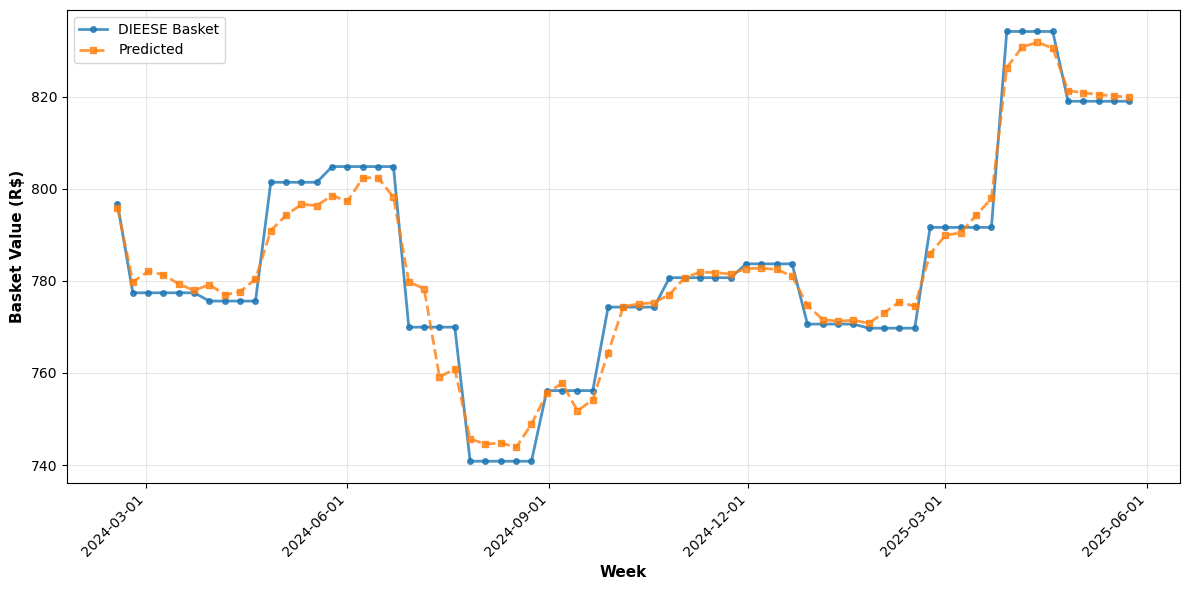

In [28]:
# Pegar datas originais do DataFrame (alinhadas com y)
dates = pd.to_datetime(df['week'].values[:len(y)])
 
# Gráfico de Série Temporal
plt.figure(figsize=(12, 6))
plt.plot(dates, y, 'o-', label='DIEESE Basket', linewidth=2, markersize=4, color='#1f77b4', alpha=0.8)
plt.plot(dates, y_pred, 's--', label='Predicted', linewidth=2, markersize=4, color='#ff7f0e', alpha=0.8)
plt.xlabel('Week', fontsize=11, fontweight='bold')
plt.ylabel('Basket Value (R$)', fontsize=11, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
 
# Formatar datas no eixo X
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45, ha='right')
 
plt.tight_layout()
plt.show()

In [29]:
# Valores shapĺey
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X)

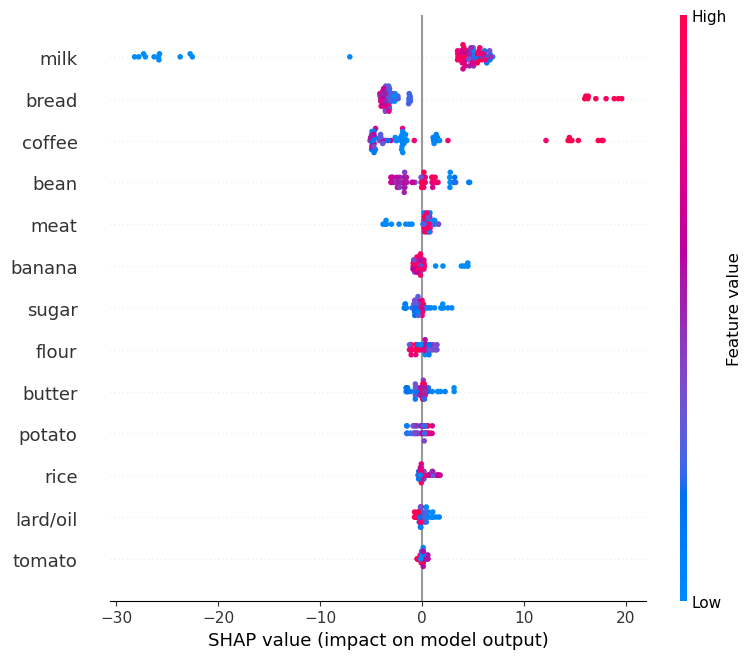

In [30]:
# shap beer plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X, plot_type="dot", show=False)
plt.tight_layout()
plt.show()

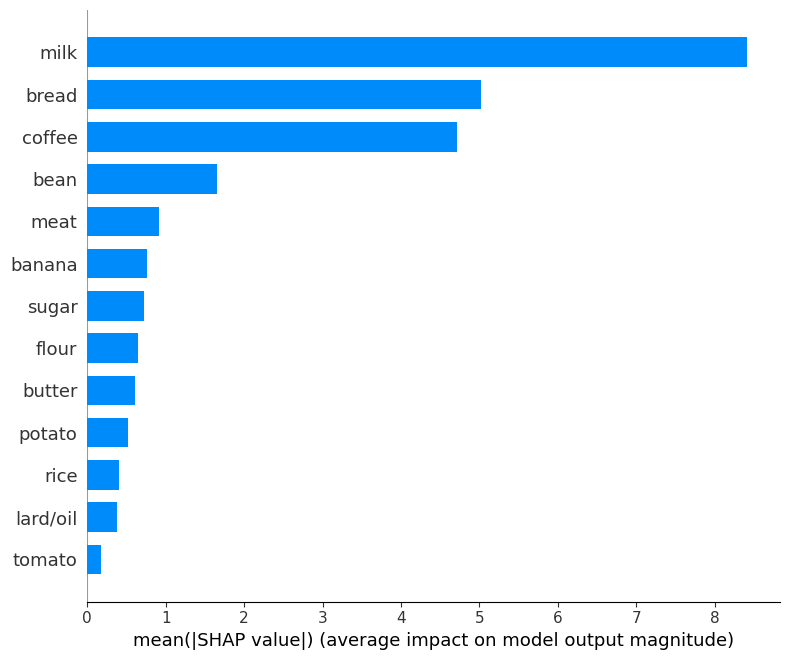

In [31]:
# shap bar plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

## Ridge

In [32]:
#function Optuna -- Ridge
def objective(trial):
    # 1. Define hyperparameters to tune
    alpha = trial.suggest_float('alpha', 1e-5, 1e2, log=True)
        
    # 2. Expanding window parameters
    initial_train_size = 10  # Starting length of training data
    step_size = 1            # How much to expand the window per step
    total_samples = len(X)
    
    scores = []
    
    # 3. Walk-forward expanding window loop
    for train_end in range(initial_train_size, total_samples, step_size):
        X_train = X[:train_end]
        y_train = y[:train_end]
        
        # Validation window directly follows the training window
        X_val = X[train_end:train_end + step_size]
        y_val = y[train_end:train_end + step_size]
        
        if len(y_val) == 0:
            break
            
        # 4. Train and predict
        model = Ridge(
            alpha=alpha,
            random_state=42
        )
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        
        # 5. Evaluate and store score
        rmse = root_mean_squared_error(y_val, preds)
        scores.append(rmse)
        
    # Return the mean error across all expanding window splits
    return np.mean(scores)

In [33]:
#run Optuna Ridge
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=20)

[I 2026-06-29 16:40:03,262] A new study created in memory with name: no-name-8f8f4d4f-fe3e-442b-8677-3ea202a2d888
[I 2026-06-29 16:40:03,353] Trial 0 finished with value: 18.233111045494322 and parameters: {'alpha': 0.004185822729546971}. Best is trial 0 with value: 18.233111045494322.
[I 2026-06-29 16:40:03,438] Trial 1 finished with value: 13.800971835883566 and parameters: {'alpha': 45.18560951024108}. Best is trial 1 with value: 13.800971835883566.
[I 2026-06-29 16:40:03,519] Trial 2 finished with value: 13.239785607080515 and parameters: {'alpha': 1.330324510152291}. Best is trial 2 with value: 13.239785607080515.
[I 2026-06-29 16:40:03,602] Trial 3 finished with value: 15.304421592913299 and parameters: {'alpha': 0.1550991398759431}. Best is trial 2 with value: 13.239785607080515.
[I 2026-06-29 16:40:03,685] Trial 4 finished with value: 20.57882874910616 and parameters: {'alpha': 0.000123631882770522}. Best is trial 2 with value: 13.239785607080515.
[I 2026-06-29 16:40:03,766] Tr

In [34]:
#best hyperparameters Ridge
print("Best hyperparameters: ", study.best_params)

Best hyperparameters:  {'alpha': 6.512613790583885}


In [35]:
# Treinar modelo final
best_model = Ridge(
    alpha=study.best_params['alpha'],
    random_state=42
)

best_model.fit(X, y)
y_pred = best_model.predict(X)

# Calcular métricas
rmse = np.sqrt(mean_squared_error(y, y_pred))
mae = mean_absolute_error(y, y_pred)
mape = calculate_mape(y, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"MAPE: {mape:.4f}%")

RMSE: 13.6478
MAE:  10.8419
MAPE: 1.3823%


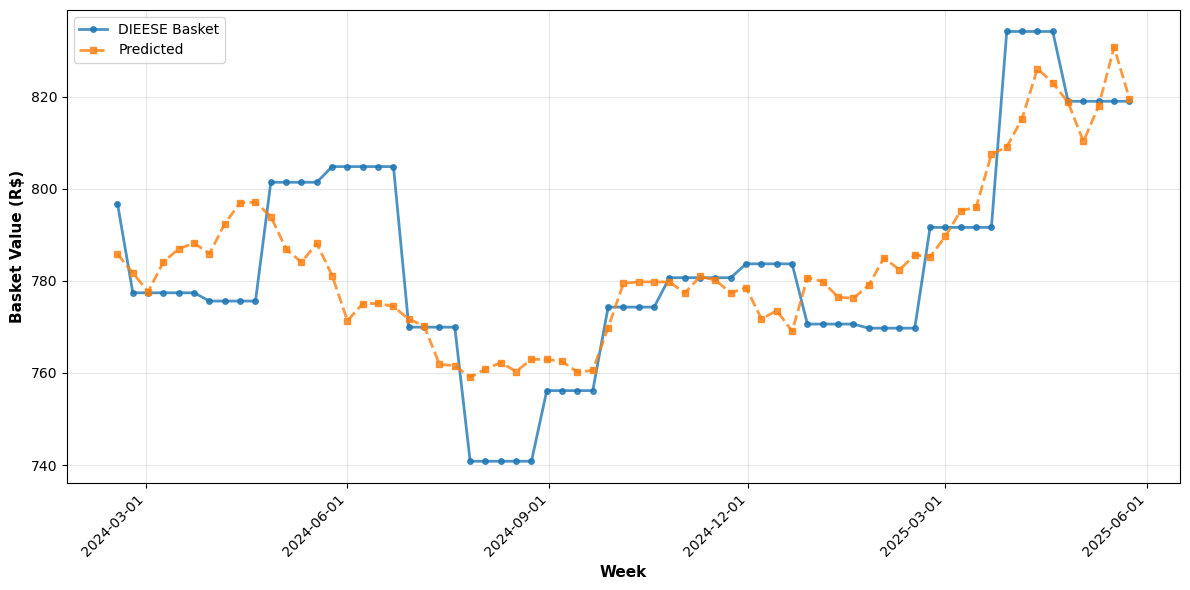

In [36]:
# Pegar datas originais do DataFrame (alinhadas com y)
dates = pd.to_datetime(df['week'].values[:len(y)])
 
# Gráfico de Série Temporal
plt.figure(figsize=(12, 6))
plt.plot(dates, y, 'o-', label='DIEESE Basket', linewidth=2, markersize=4, color='#1f77b4', alpha=0.8)
plt.plot(dates, y_pred, 's--', label='Predicted', linewidth=2, markersize=4, color='#ff7f0e', alpha=0.8)
plt.xlabel('Week', fontsize=11, fontweight='bold')
plt.ylabel('Basket Value (R$)', fontsize=11, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
 
# Formatar datas no eixo X
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45, ha='right')
 
plt.tight_layout()
plt.show()

Ao executa o explainer abaixo gerou erro para o algoritmo `Ridge`. InvalidModelError: Model type not yet supported by TreeExplainer: <class 'sklearn.linear_model._ridge.Ridge'>

In [37]:
# Valores shapĺey
# explainer = shap.TreeExplainer(best_model)
# shap_values = explainer.shap_values(X)

## KNN

In [38]:
#function Optuna -- kNN
def objective(trial):
    # 1. Define hyperparameters to tune
    n_neighbors = trial.suggest_int('n_neighbors', 1, 10)
    weights = trial.suggest_categorical('weights', ['uniform', 'distance'])
    metric = trial.suggest_categorical('metric', ['euclidean', 'manhattan'])
        
    # 2. Expanding window parameters
    initial_train_size = 10  # Starting length of training data
    step_size = 1            # How much to expand the window per step
    total_samples = len(X)
    
    scores = []
    
    # 3. Walk-forward expanding window loop
    for train_end in range(initial_train_size, total_samples, step_size):
        X_train = X[:train_end]
        y_train = y[:train_end]
        
        # Validation window directly follows the training window
        X_val = X[train_end:train_end + step_size]
        y_val = y[train_end:train_end + step_size]
        
        if len(y_val) == 0:
            break
            
        # 4. Train and predict
        model = KNeighborsRegressor(
            n_neighbors=n_neighbors,
            weights=weights,
            metric=metric
        )
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        
        # 5. Evaluate and store score
        rmse = root_mean_squared_error(y_val, preds)
        scores.append(rmse)
        
    # Return the mean error across all expanding window splits
    return np.mean(scores)

In [39]:
#run Optuna knn
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=20)

[I 2026-06-29 16:40:05,184] A new study created in memory with name: no-name-ed1a5e5d-28ba-4cfe-b8cd-32e7b3e20302
[I 2026-06-29 16:40:05,294] Trial 0 finished with value: 11.546754385964928 and parameters: {'n_neighbors': 4, 'weights': 'uniform', 'metric': 'euclidean'}. Best is trial 0 with value: 11.546754385964928.
[I 2026-06-29 16:40:05,381] Trial 1 finished with value: 7.6407815208941114 and parameters: {'n_neighbors': 2, 'weights': 'distance', 'metric': 'manhattan'}. Best is trial 1 with value: 7.6407815208941114.
[I 2026-06-29 16:40:05,471] Trial 2 finished with value: 7.351403508771935 and parameters: {'n_neighbors': 1, 'weights': 'uniform', 'metric': 'euclidean'}. Best is trial 2 with value: 7.351403508771935.
[I 2026-06-29 16:40:05,559] Trial 3 finished with value: 9.128738020110887 and parameters: {'n_neighbors': 2, 'weights': 'distance', 'metric': 'euclidean'}. Best is trial 2 with value: 7.351403508771935.
[I 2026-06-29 16:40:05,686] Trial 4 finished with value: 11.52607772

In [40]:
#best hyperparameters knn
print("Best hyperparameters: ", study.best_params)

Best hyperparameters:  {'n_neighbors': 1, 'weights': 'uniform', 'metric': 'euclidean'}


In [41]:
# Treinar modelo final
best_model = KNeighborsRegressor(
    n_neighbors=study.best_params['n_neighbors'],
    weights=study.best_params['weights'],
    metric=study.best_params['metric']
)
best_model.fit(X, y)
y_pred = best_model.predict(X)

# Calcular métricas
rmse = np.sqrt(mean_squared_error(y, y_pred))
mae = mean_absolute_error(y, y_pred)
mape = calculate_mape(y, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"MAPE: {mape:.4f}%")

RMSE: 0.0000
MAE:  0.0000
MAPE: 0.0000%


## XGBoost

In [42]:
#function Optuna -- XGB
def objective(trial):
    # 1. Define hyperparameters to tune
    max_depth = trial.suggest_int('max_depth', 3, 10)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.1)
    n_estimators = trial.suggest_int('n_estimators', 10, 200)
    subsample = trial.suggest_float('subsample', 0.5, 1.0)
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0)
    min_child_weight = trial.suggest_int('min_child_weight', 1, 10)
    gamma = trial.suggest_float('gamma', 0, 5)
        
    # 2. Expanding window parameters
    initial_train_size = 10  # Starting length of training data
    step_size = 1            # How much to expand the window per step
    total_samples = len(X)
    
    scores = []
    
    # 3. Walk-forward expanding window loop
    for train_end in range(initial_train_size, total_samples, step_size):
        X_train = X[:train_end]
        y_train = y[:train_end]
        
        # Validation window directly follows the training window
        X_val = X[train_end:train_end + step_size]
        y_val = y[train_end:train_end + step_size]
        
        if len(y_val) == 0:
            break
            
        # 4. Train and predict
        model = XGBRegressor(
            max_depth = max_depth,
            learning_rate = learning_rate,
            n_estimators = n_estimators,
            subsample = subsample,
            colsample_bytree = colsample_bytree,
            min_child_weight = min_child_weight,
            gamma = gamma
        )
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        
        # 5. Evaluate and store score
        rmse = root_mean_squared_error(y_val, preds)
        scores.append(rmse)
        
    # Return the mean error across all expanding window splits
    return np.mean(scores)

In [43]:
#run Optuna XGB
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=20)

[I 2026-06-29 16:40:07,062] A new study created in memory with name: no-name-d3faa19b-3fbd-4595-af0c-9bab1c3a193b
[I 2026-06-29 16:40:13,685] Trial 0 finished with value: 10.166407406455589 and parameters: {'max_depth': 5, 'learning_rate': 0.09556428757689246, 'n_estimators': 149, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'min_child_weight': 2, 'gamma': 0.2904180608409973}. Best is trial 0 with value: 10.166407406455589.
[I 2026-06-29 16:40:18,581] Trial 1 finished with value: 13.931611884936954 and parameters: {'max_depth': 9, 'learning_rate': 0.0641003510568888, 'n_estimators': 145, 'subsample': 0.5102922471479012, 'colsample_bytree': 0.9849549260809971, 'min_child_weight': 9, 'gamma': 1.0616955533913808}. Best is trial 0 with value: 10.166407406455589.
[I 2026-06-29 16:40:22,181] Trial 2 finished with value: 12.631342088130477 and parameters: {'max_depth': 4, 'learning_rate': 0.026506405886809047, 'n_estimators': 68, 'subsample': 0.762378215816119, 'co

In [44]:
#best hyperparameters Ridge
print("Best hyperparameters: ", study.best_params)

Best hyperparameters:  {'max_depth': 8, 'learning_rate': 0.05484887024994947, 'n_estimators': 164, 'subsample': 0.7562750052240121, 'colsample_bytree': 0.6044566965112071, 'min_child_weight': 1, 'gamma': 1.2019881286803893}


In [45]:
# Treinar modelo final
best_model = XGBRegressor(
    max_depth=study.best_params['max_depth'],
    learning_rate=study.best_params['learning_rate'],
    n_estimators=study.best_params['n_estimators'],
    subsample=study.best_params['subsample'],
    alpcolsample_bytreeha=study.best_params['colsample_bytree'],
    min_child_weight=study.best_params['min_child_weight'],
    gamma=study.best_params['gamma'],
    random_state=42
)

best_model.fit(X, y)
y_pred = best_model.predict(X)

# Calcular métricas
rmse = np.sqrt(mean_squared_error(y, y_pred))
mae = mean_absolute_error(y, y_pred)
mape = calculate_mape(y, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"MAPE: {mape:.4f}%")

RMSE: 0.5573
MAE:  0.4042
MAPE: 0.0517%


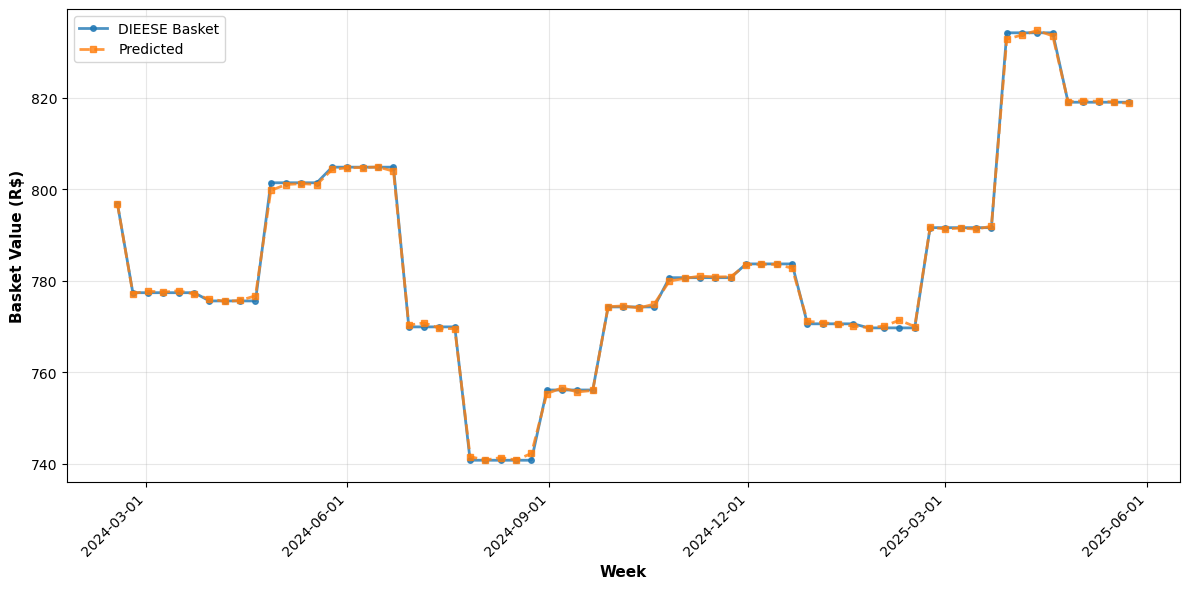

In [46]:
# Pegar datas originais do DataFrame (alinhadas com y)
dates = pd.to_datetime(df['week'].values[:len(y)])
 
# Gráfico de Série Temporal
plt.figure(figsize=(12, 6))
plt.plot(dates, y, 'o-', label='DIEESE Basket', linewidth=2, markersize=4, color='#1f77b4', alpha=0.8)
plt.plot(dates, y_pred, 's--', label='Predicted', linewidth=2, markersize=4, color='#ff7f0e', alpha=0.8)
plt.xlabel('Week', fontsize=11, fontweight='bold')
plt.ylabel('Basket Value (R$)', fontsize=11, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
 
# Formatar datas no eixo X
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45, ha='right')
 
plt.tight_layout()
plt.show()

In [47]:
# Valores shapĺey
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X)

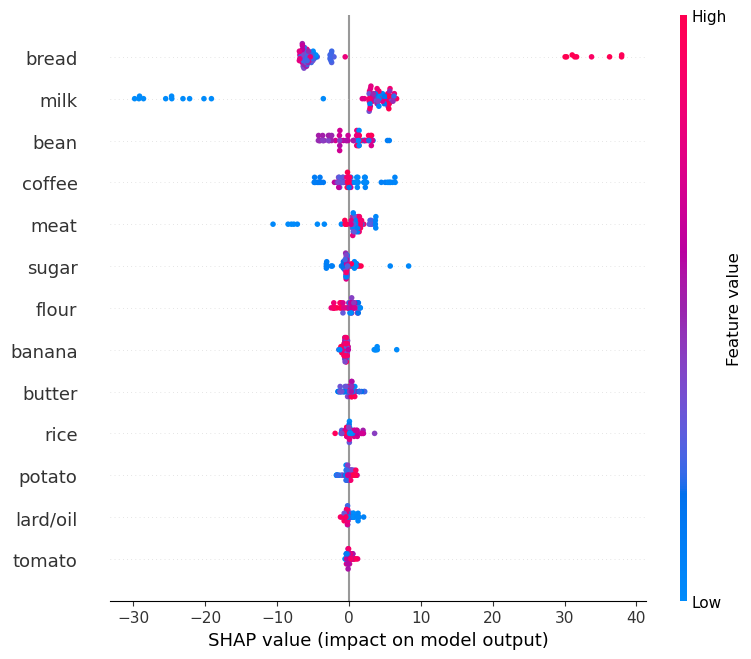

In [48]:
# shap beer plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X, plot_type="dot", show=False)
plt.tight_layout()
plt.show()

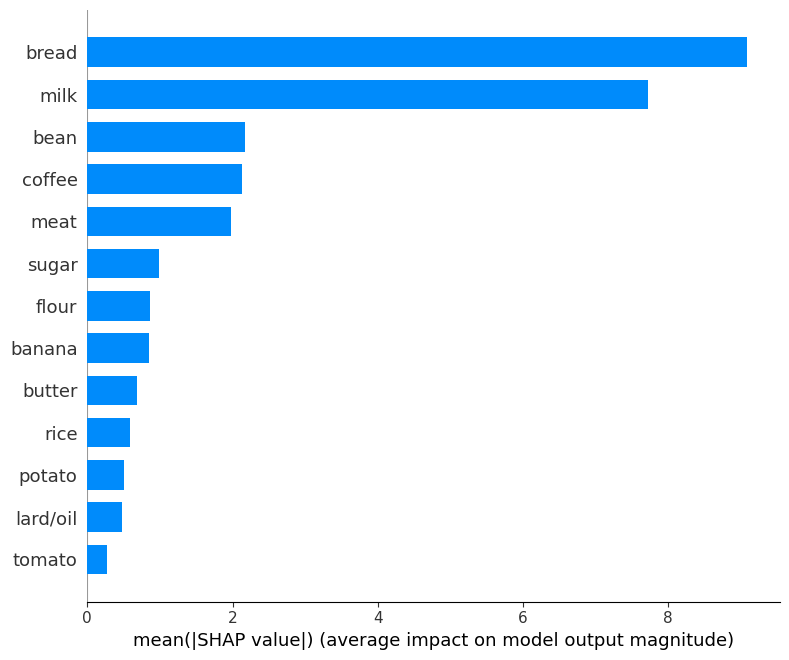

In [49]:
# shap bar plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

## VotinRegressor

In [50]:
#function Optuna -- Voting Regressor
def objective(trial):
    # 1. Define hyperparameters to tune
    rf_n_estimators = trial.suggest_int('rf_n_estimators', 50, 200)
    rf_max_leaf_nodes = trial.suggest_int('rf_max_leaf_nodes', 2, 256)
    rf_min_samples_split = trial.suggest_int('rf_min_samples_split', 5, 100)
    rf_max_depth = trial.suggest_int('rf_max_depth', 5, 20, log=True)
    
    ridge_alpha = trial.suggest_float('ridge_alpha', 0.1, 100)
    
    knn_neighbors = trial.suggest_int('knn_neighbors', 1, 10)
    knn_weights = trial.suggest_categorical('knn_weights', ['uniform', 'distance'])
    
    xgb_max_depth = trial.suggest_int('xgb_max_depth', 3, 10)
    xgb_learning_rate = trial.suggest_float('xgb_learning_rate', 0.01, 0.3)
    xgb_n_estimators = trial.suggest_int('xgb_n_estimators', 50, 200)
    
    # 2. Expanding window parameters
    initial_train_size = 10
    step_size = 1
    total_samples = len(X)
    
    scores = []
    
    # 3. Walk-forward expanding window loop
    for train_end in range(initial_train_size, total_samples, step_size):
        X_train = X[:train_end]
        y_train = y[:train_end]
        
        X_val = X[train_end:train_end + step_size]
        y_val = y[train_end:train_end + step_size]
        
        if len(y_val) == 0:
            break
            
        # 4. Train and predict
        rf_model = RandomForestRegressor(
            n_estimators=rf_n_estimators,
            max_leaf_nodes=rf_max_leaf_nodes,
            min_samples_split=rf_min_samples_split,
            max_depth=rf_max_depth,
            random_state=42
        )
        
        ridge_model = Ridge(alpha=ridge_alpha)
        
        knn_model = KNeighborsRegressor(
            n_neighbors=knn_neighbors,
            weights=knn_weights
        )
        
        xgb_model = XGBRegressor(
            max_depth=xgb_max_depth,
            learning_rate=xgb_learning_rate,
            n_estimators=xgb_n_estimators,
            random_state=42
        )
        
        voting_model = VotingRegressor(
            estimators=[('rf', rf_model), ('ridge', ridge_model), ('knn', knn_model), ('xgb', xgb_model)]
        )
        
        voting_model.fit(X_train, y_train)
        preds = voting_model.predict(X_val)
        
        # 5. Evaluate and store score
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        scores.append(rmse)
        
    # Return the mean error across all expanding window splits
    return np.mean(scores)

In [51]:
#run Optuna Voting Regressor
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=20)

[I 2026-06-29 16:42:08,717] A new study created in memory with name: no-name-99817fd0-399a-494a-bf5a-ea5ffc3e3846
[I 2026-06-29 16:42:16,183] Trial 0 finished with value: 11.415776063239866 and parameters: {'rf_n_estimators': 106, 'rf_max_leaf_nodes': 244, 'rf_min_samples_split': 75, 'rf_max_depth': 11, 'ridge_alpha': 15.686262180199408, 'knn_neighbors': 2, 'knn_weights': 'distance', 'xgb_max_depth': 7, 'xgb_learning_rate': 0.21534104756085318, 'xgb_n_estimators': 53}. Best is trial 0 with value: 11.415776063239866.
[I 2026-06-29 16:42:26,704] Trial 1 finished with value: 11.598006087173298 and parameters: {'rf_n_estimators': 196, 'rf_max_leaf_nodes': 214, 'rf_min_samples_split': 25, 'rf_max_depth': 6, 'ridge_alpha': 18.42211053435804, 'knn_neighbors': 4, 'knn_weights': 'uniform', 'xgb_max_depth': 5, 'xgb_learning_rate': 0.18743733946949004, 'xgb_n_estimators': 71}. Best is trial 0 with value: 11.415776063239866.
[I 2026-06-29 16:42:34,143] Trial 2 finished with value: 12.8255455222771

In [52]:
#best hyperparameters Voting Regressor
print("Best hyperparameters: ", study.best_params)

Best hyperparameters:  {'rf_n_estimators': 113, 'rf_max_leaf_nodes': 68, 'rf_min_samples_split': 5, 'rf_max_depth': 20, 'ridge_alpha': 67.42069496418958, 'knn_neighbors': 3, 'knn_weights': 'distance', 'xgb_max_depth': 4, 'xgb_learning_rate': 0.2537557856012104, 'xgb_n_estimators': 164}


In [53]:
# Treinar modelo final
best_model = VotingRegressor(
    estimators=[
        ('rf', RandomForestRegressor(
            n_estimators=study.best_params['rf_n_estimators'],
            max_leaf_nodes=study.best_params['rf_max_leaf_nodes'],
            min_samples_split=study.best_params['rf_min_samples_split'],
            max_depth=study.best_params['rf_max_depth'],
            random_state=42
        )),
        ('ridge', Ridge(alpha=study.best_params['ridge_alpha'])),
        ('knn', KNeighborsRegressor(
            n_neighbors=study.best_params['knn_neighbors'],
            weights=study.best_params['knn_weights']
        )),
        ('xgb', XGBRegressor(
            max_depth=study.best_params['xgb_max_depth'],
            learning_rate=study.best_params['xgb_learning_rate'],
            n_estimators=study.best_params['xgb_n_estimators'],
            random_state=42
        ))
    ]
)
 
best_model.fit(X, y)
y_pred = best_model.predict(X)

# Calcular métricas
rmse = np.sqrt(mean_squared_error(y, y_pred))
mae = mean_absolute_error(y, y_pred)
mape = calculate_mape(y, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"MAPE: {mape:.4f}%")

RMSE: 4.5923
MAE:  3.6564
MAPE: 0.4671%


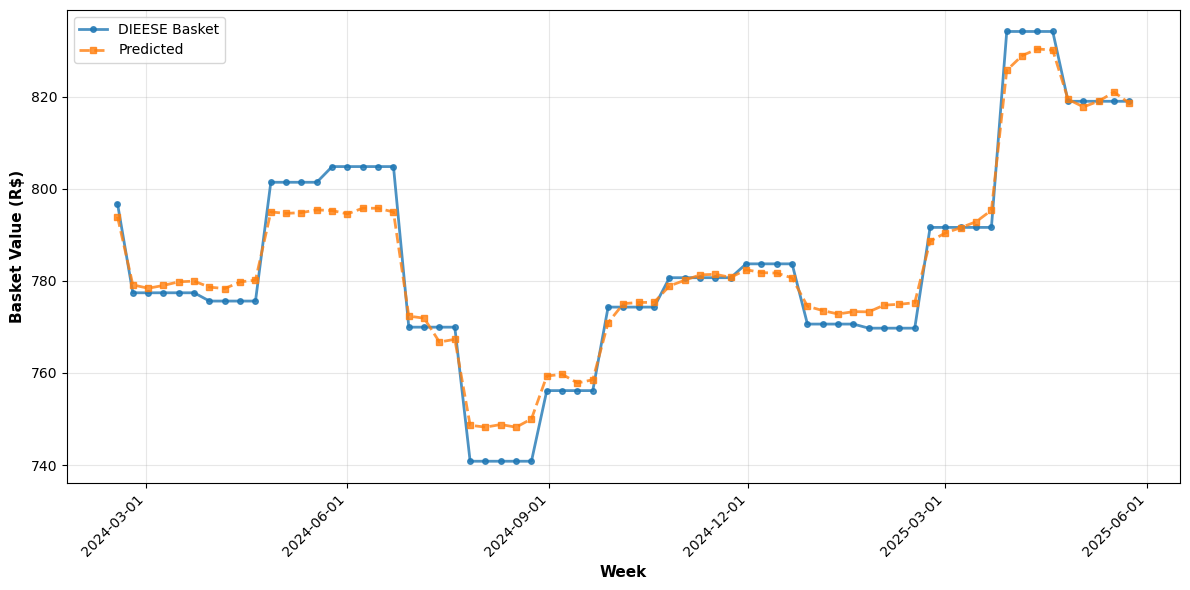

In [54]:
# Pegar datas originais do DataFrame (alinhadas com y)
dates = pd.to_datetime(df['week'].values[:len(y)])
 
# Gráfico de Série Temporal
plt.figure(figsize=(12, 6))
plt.plot(dates, y, 'o-', label='DIEESE Basket', linewidth=2, markersize=4, color='#1f77b4', alpha=0.8)
plt.plot(dates, y_pred, 's--', label='Predicted', linewidth=2, markersize=4, color='#ff7f0e', alpha=0.8)
plt.xlabel('Week', fontsize=11, fontweight='bold')
plt.ylabel('Basket Value (R$)', fontsize=11, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
 
# Formatar datas no eixo X
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45, ha='right')
 
plt.tight_layout()
plt.show()